<a href="https://colab.research.google.com/github/250227018/EduTech-Internship-Task1/blob/main/Crop_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sakshitiwariji23","key":"f1cec18c51063e74137a9e05260c1d94"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:16<00:00, 171MB/s]



In [5]:
import os

train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

classes = os.listdir(train_dir)
print("Total classes:", len(classes))
print(classes[:5])

sample_class = classes[0]
sample_path = os.path.join(train_dir, sample_class)
print(f"\n'{sample_class}' me images:", len(os.listdir(sample_path)))

Total classes: 38
['Soybean___healthy', 'Strawberry___healthy', 'Corn_(maize)___healthy', 'Potato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

'Soybean___healthy' me images: 2022


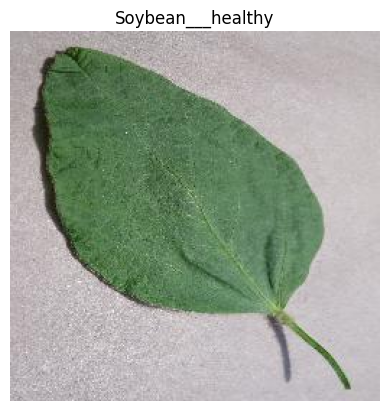

Image size: (256, 256)


In [6]:
import matplotlib.pyplot as plt
from PIL import Image

sample_img_name = os.listdir(sample_path)[0]
sample_img = Image.open(os.path.join(sample_path, sample_img_name))

plt.imshow(sample_img)
plt.title(sample_class)
plt.axis('off')
plt.show()

print("Image size:", sample_img.size)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128   # 256 se chhota rakhenge, taaki training fast ho
BATCH_SIZE = 32

# Training data: normalize + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Validation data: sirf normalize (augmentation nahi)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(38, activation='softmax')   # 38 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 456s 204ms/step - accuracy: 0.5026 - loss: 1.6803 - val_accuracy: 0.6795 - val_loss: 1.0705
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 427s 194ms/step - accuracy: 0.7366 - loss: 0.8431 - val_accuracy: 0.8314 - val_loss: 0.5280
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 435s 198ms/step - accuracy: 0.8017 - loss: 0.6275 - val_accuracy: 0.8725 - val_loss: 0.3950
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 419s 191ms/step - accuracy: 0.8375 - loss: 0.5082 - val_accuracy: 0.8859 - val_loss: 0.3573
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 434s 198ms/step - accuracy: 0.8585 - loss: 0.4448 - val_accuracy: 0.8973 - val_loss: 0.3200
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 417s 190ms/step - accuracy: 0.8741 - loss: 0.3918 - val_accuracy: 0.8984 - val_loss: 0.3266
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 436s 198ms/step - accuracy: 0.8876 - loss: 0.3553 - val_accuracy: 0.9273 - val_loss: 0.2255
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 427s 194ms/step - ac

In [11]:
model.save('/content/crop_disease_model.keras')

from google.colab import files
files.download('/content/crop_disease_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

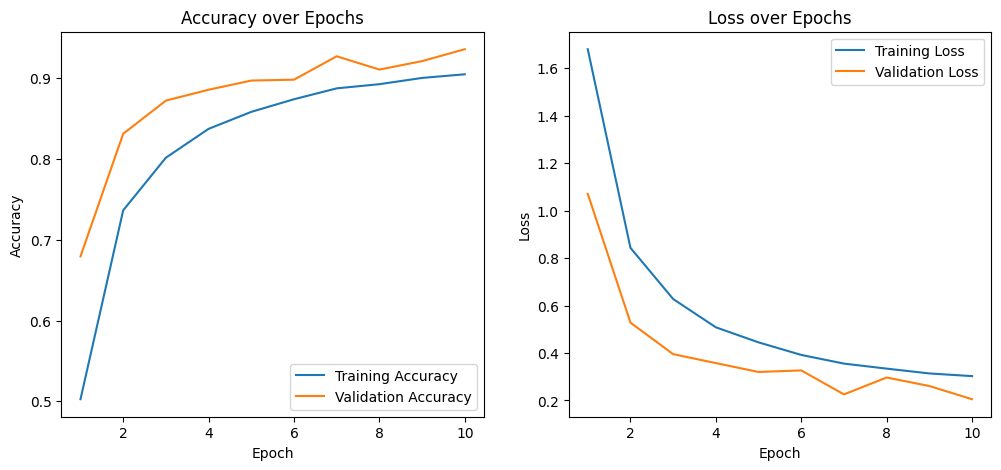

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.savefig('/content/training_graph.png')
plt.show()
